Text(0, 0.5, 'Frequenza')

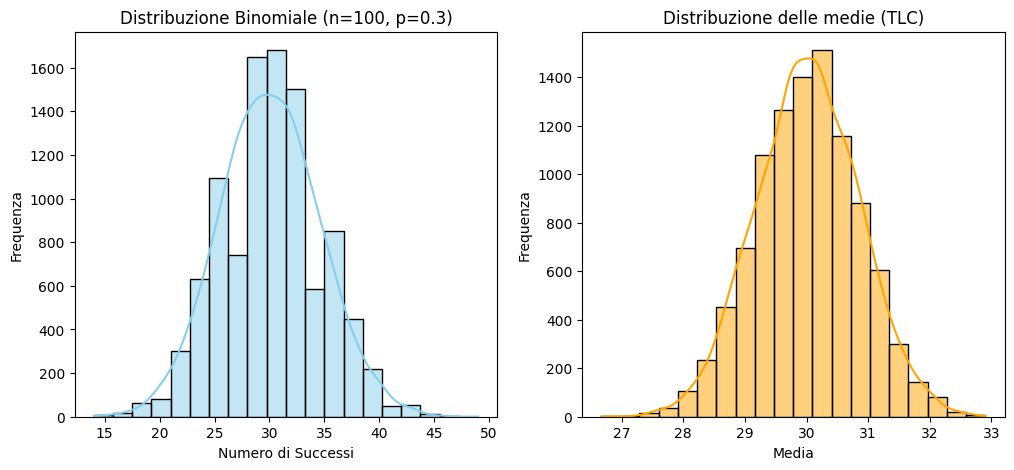

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#alternativa 
import scipy.stats as st

#Parametri della distribuzione binomiale 
n_prove = 100 #Numero prove per ogni campione (es. 100 lanci di una moneta)
p_successo = 0.3 #Probabilità di successo (es. 30% di successo)
n_campioni = 10000 #Numero di campioni da estrarre 

#1. Generare i campioni
#Ogni elemento nel risultato sarà il numero di successi in n_prove, per ciascuno dei n_campioni
risultati_campioni = np.random.binomial(n=n_prove, p=p_successo, size=n_campioni)

#Oppure: Generazione dei campioni
risultati_campioni = st.binom.rvs(n=n_prove, p=p_successo, size=n_campioni)

#2. Calcolare la media di ogni campione (anche se qui stiamo facendo una simulazione diretta
#delle distribuzioni, la logica del TLC è su un altro livello di campionamento, vediamo qui l'istogramma
#della distribuzione binomiale stessa, che sarà approssimativamente normale).
#Per vedere il TLC: si campiona *da* questa distribuzione tante volte
#oppure si campionano N volte *da* una binomiale e si fa l'istogramma delle medie. 

#Esempio
medie_campioni = []
n_campioni_per_TLC = 10000 #Quante volte calcoliamo la media
dimensione_campione_TLC = 30 #Grandezza di ogni singolo "micro-campione"

for _ in range(n_campioni_per_TLC):
    #Estraiamo un campione di dimensione 'dimensione_campione_TLC' dalla nostra binomiale
    campione = np.random.binomial (n=n_prove, p=p_successo, size=dimensione_campione_TLC)
    medie_campioni.append(np.mean(campione))

#3. Visualizzare
plt.figure(figsize=(12, 5))

#Istogramma della distribuzione binomiale (per n=100, p=0.3)
plt.subplot(1, 2, 1)
sns.histplot(risultati_campioni, bins=20, kde=True, color='skyblue')
plt.title(f'Distribuzione Binomiale (n={n_prove}, p={p_successo})')
plt.xlabel('Numero di Successi')
plt.ylabel('Frequenza')

#Istogramma delle medie (per il TLC)
plt.subplot(1, 2, 2)
sns.histplot(medie_campioni, bins=20, kde=True, color='orange')
plt.title('Distribuzione delle medie (TLC)')
plt.xlabel('Media')
plt.ylabel('Frequenza')